# Práctica 9

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/manuxch/calculo_avanzado/blob/main/09-aproximacion_minimos_cuadrados/code/practica_09.ipynb)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
np.set_printoptions(precision=6, suppress=True)

---
## Ejercicio 5

### 5.1 El problema

El ensayo de una bomba centrífuga entrega, para cada apertura de la válvula de
descarga, un par caudal-altura $(Q_i, H_i)$. Las mediciones tienen **dispersión
experimental** (error del caudalímetro, fluctuaciones de presión, lectura de
manómetros), de modo que **no tiene sentido** hacer pasar una curva exactamente
por los $m$ puntos: eso ajustaría el ruido, no la física.

La teoría de turbomáquinas indica que, para velocidad de giro constante, la curva
característica real es aproximadamente parabólica,

$$ H(Q) \approx a_0 + a_1 Q + a_2 Q^2, $$

con $a_0 > 0$ (altura a caudal nulo, *shutoff head*) y $a_2 < 0$. Buscamos entonces
el polinomio de grado $n = 2$ que minimiza

$$ E = \sum_{i=1}^{m} \left[ H_i - P_2(Q_i) \right]^2 . $$

### 5.2 Ecuaciones normales

Para un polinomio $P_n(x) = \sum_{k=0}^{n} a_k x^k$ ajustado a $\{(x_i, y_i)\}_{i=1}^{m}$,
la condición $\partial E / \partial a_j = 0$ conduce al sistema de $n+1$ ecuaciones

$$ \sum_{k=0}^{n} a_k \sum_{i=1}^{m} x_i^{\,j+k} \;=\; \sum_{i=1}^{m} y_i \, x_i^{\,j},
\qquad j = 0, 1, \dots, n . $$

Definiendo $S_p = \sum_{i=1}^m x_i^{\,p}$ y $T_j = \sum_{i=1}^m y_i x_i^{\,j}$, para $n = 2$:

$$
\begin{bmatrix}
S_0 & S_1 & S_2 \\
S_1 & S_2 & S_3 \\
S_2 & S_3 & S_4
\end{bmatrix}
\begin{bmatrix} a_0 \\ a_1 \\ a_2 \end{bmatrix}
=
\begin{bmatrix} T_0 \\ T_1 \\ T_2 \end{bmatrix},
\qquad S_0 = m .
$$

Obsérvese que la matriz es **simétrica** y depende solo de las abscisas.

## 5.3 Datos del ensayo

Caudal $Q$ en $\mathrm{m^3/h}$, altura manométrica $H$ en m.

In [28]:
Q = np.array([0., 10., 20., 30., 40., 50., 60., 70., 80., 90.])
H = np.array([52.00, 51.68, 50.48, 48.75, 47.00, 44.30, 41.83, 38.95, 34.18, 29.67])
m = Q.size

for q, h in zip(Q, H):
    print(f"  Q = {q:5.1f} m^3/h    H = {h:6.2f} m")
print(f"\nm = {m} puntos de ensayo")

  Q =   0.0 m^3/h    H =  52.00 m
  Q =  10.0 m^3/h    H =  51.68 m
  Q =  20.0 m^3/h    H =  50.48 m
  Q =  30.0 m^3/h    H =  48.75 m
  Q =  40.0 m^3/h    H =  47.00 m
  Q =  50.0 m^3/h    H =  44.30 m
  Q =  60.0 m^3/h    H =  41.83 m
  Q =  70.0 m^3/h    H =  38.95 m
  Q =  80.0 m^3/h    H =  34.18 m
  Q =  90.0 m^3/h    H =  29.67 m

m = 10 puntos de ensayo


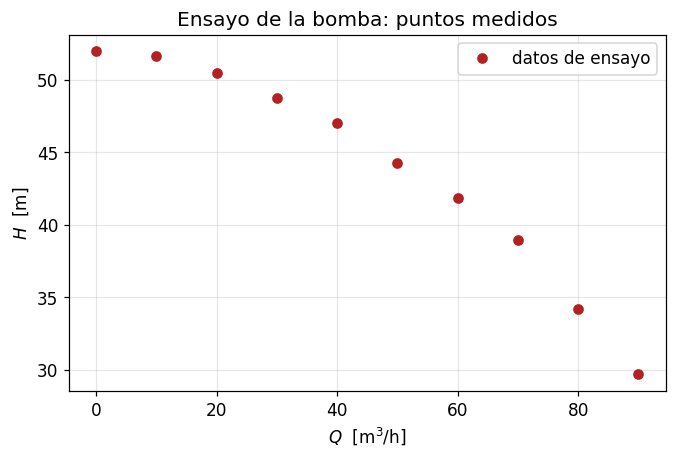

In [29]:
fig, ax = plt.subplots()
ax.plot(Q, H, "o", color="firebrick", label="datos de ensayo")
ax.set_xlabel(r"$Q$  [m$^3$/h]")
ax.set_ylabel(r"$H$  [m]")
ax.set_title("Ensayo de la bomba: puntos medidos")
ax.legend()
plt.show()

### 5.4 Construcción y resolución del sistema normal

Armamos la matriz de sumas $S_{j+k}$ y el vector $T_j$ tal como aparecen en la
deducción teórica, sin usar ninguna rutina de ajuste.

In [30]:
n = 2                                  # grado del polinomio

S = np.array([np.sum(Q**p) for p in range(2*n + 1)])      # S_0 ... S_4
T = np.array([np.sum(H * Q**j) for j in range(n + 1)])    # T_0 ... T_2

A = np.array([[S[j + k] for k in range(n + 1)] for j in range(n + 1)])

print("S_p =", S)
print("T_j =", T)
print("\nMatriz del sistema normal A:")
print(A)

S_p = [1.0000e+01 4.5000e+02 2.8500e+04 2.0250e+06 1.5333e+08]
T_j = [    438.84   17724.9  1055707.  ]

Matriz del sistema normal A:
[[1.0000e+01 4.5000e+02 2.8500e+04]
 [4.5000e+02 2.8500e+04 2.0250e+06]
 [2.8500e+04 2.0250e+06 1.5333e+08]]


In [31]:
a = np.linalg.solve(A, T)
print(f"a_0 = {a[0]:12.6f}   m")
print(f"a_1 = {a[1]:12.6f}   m/(m^3/h)")
print(f"a_2 = {a[2]:12.6f}   m/(m^3/h)^2")
print(f"\nH(Q) = {a[0]:.3f} {a[1]:+.4f} Q {a[2]:+.6f} Q^2")

a_0 =    51.980273   m
a_1 =    -0.024870   m/(m^3/h)
a_2 =    -0.002448   m/(m^3/h)^2

H(Q) = 51.980 -0.0249 Q -0.002448 Q^2


### 5.5 Verificación con `polyfit` y `lstsq`

`numpy.polyfit` devuelve los coeficientes en orden de potencia **decreciente**;
`numpy.linalg.lstsq` resuelve el problema sobredeterminado $V a \simeq y$ por
descomposición en valores singulares, sin formar nunca la matriz normal $A = V^T V$.

In [32]:
a_polyfit = np.polyfit(Q, H, n)[::-1]          # se invierte: a_0, a_1, a_2

V = np.vander(Q, n + 1, increasing=True)       # matriz de Vandermonde, m x (n+1)
a_lstsq, *_ = np.linalg.lstsq(V, H, rcond=None)

print("ecuaciones normales :", a)
print("np.polyfit          :", a_polyfit)
print("np.linalg.lstsq     :", a_lstsq)
print("\ndiferencia máxima   :", np.max(np.abs(a - a_lstsq)))

ecuaciones normales : [51.980273 -0.02487  -0.002448]
np.polyfit          : [51.980273 -0.02487  -0.002448]
np.linalg.lstsq     : [51.980273 -0.02487  -0.002448]

diferencia máxima   : 1.3500311979441904e-13


Los tres caminos coinciden. La identidad $A = V^{T} V$ y $T = V^{T} y$ muestra que
las ecuaciones normales no son más que la forma explícita del problema
$\min \| V a - y \|_2$.

In [33]:
print("A  == V^T V :", np.allclose(A, V.T @ V))
print("T  == V^T y :", np.allclose(T, V.T @ H))

A  == V^T V : True
T  == V^T y : True


### 5.6 Error de ajuste y gráfico

In [34]:
Hajuste = V @ a                     # P_2(Q_i)
res = H - Hajuste                   # residuos
E = np.sum(res**2)

print(f"E = sum (H_i - P_2(Q_i))^2 = {E:.4f} m^2")
print(f"desviación típica del ajuste = {np.sqrt(E/(m - (n+1))):.4f} m")
print(f"residuo máximo               = {np.max(np.abs(res)):.4f} m")

E = sum (H_i - P_2(Q_i))^2 = 0.8241 m^2
desviación típica del ajuste = 0.3431 m
residuo máximo               = 0.7064 m


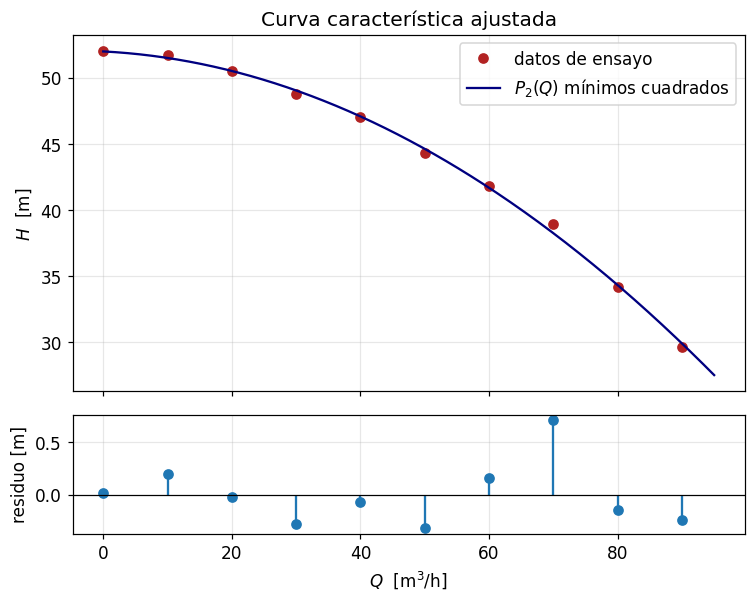

In [35]:
Qf = np.linspace(0, 95, 400)
Hf = np.polyval(a[::-1], Qf)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(Q, H, "o", color="firebrick", label="datos de ensayo")
ax1.plot(Qf, Hf, "-", color="navy", label=r"$P_2(Q)$ mínimos cuadrados")
ax1.set_ylabel(r"$H$  [m]")
ax1.set_title("Curva característica ajustada")
ax1.legend()

ax2.stem(Q, res, basefmt=" ")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel(r"$Q$  [m$^3$/h]")
ax2.set_ylabel("residuo [m]")
plt.tight_layout()
plt.show()

Los residuos no muestran estructura sistemática (no quedan tramos enteros por
encima o por debajo de cero): el modelo cuadrático es adecuado y lo que queda es
ruido de medición.

### 5.7 Punto de funcionamiento

La instalación donde se monta la bomba tiene una curva resistente

$$ H_s(Q) = H_e + K\,Q^2 ,$$

con $H_e$ la altura geométrica a vencer y $K$ el coeficiente de pérdidas. El
**punto de funcionamiento** es la intersección $H(Q) = H_s(Q)$, es decir la raíz
positiva de

$$ (a_2 - K)\,Q^2 + a_1 Q + (a_0 - H_e) = 0 .$$

Este es el resultado que realmente se usa en el diseño, y solo es accesible
*después* de haber ajustado la curva.

In [36]:
He, K = 18.0, 0.0035          # m  y  m/(m^3/h)^2

coef = [a[2] - K, a[1], a[0] - He]      # orden decreciente para np.roots
raices = np.roots(coef)
Qop = raices[(raices.real > 0) & (np.abs(raices.imag) < 1e-12)].real[0]
Hop = He + K * Qop**2

print(f"raíces          : {raices}")
print(f"Q_op = {Qop:6.2f} m^3/h")
print(f"H_op = {Hop:6.2f} m")

raíces          : [-77.702519  73.52128 ]
Q_op =  73.52 m^3/h
H_op =  36.92 m


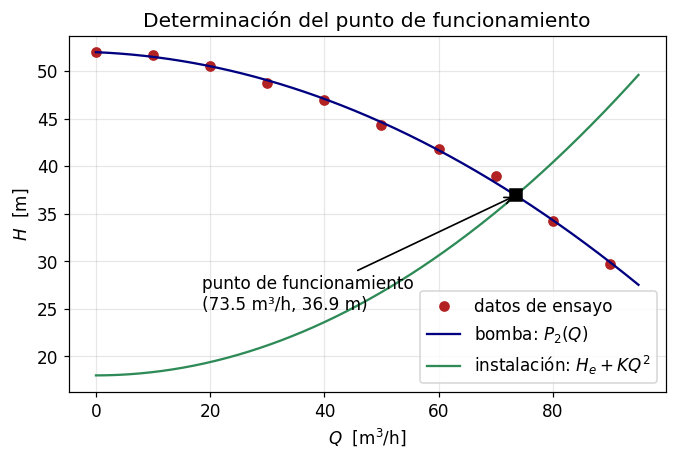

In [37]:
fig, ax = plt.subplots()
ax.plot(Q, H, "o", color="firebrick", label="datos de ensayo")
ax.plot(Qf, Hf, "-", color="navy", label=r"bomba: $P_2(Q)$")
ax.plot(Qf, He + K * Qf**2, "-", color="seagreen", label=r"instalación: $H_e + K Q^2$")
ax.plot(Qop, Hop, "s", color="black", ms=8, zorder=5)
ax.annotate(f"punto de funcionamiento\n({Qop:.1f} m³/h, {Hop:.1f} m)",
            xy=(Qop, Hop), xytext=(Qop - 55, Hop - 12),
            arrowprops=dict(arrowstyle="->", lw=1.1))
ax.set_xlabel(r"$Q$  [m$^3$/h]")
ax.set_ylabel(r"$H$  [m]")
ax.set_title("Determinación del punto de funcionamiento")
ax.legend()
plt.show()

### 5.8 Una advertencia: condicionamiento de la matriz normal

Las sumas $S_p$ crecen como $x^p$, de modo que las columnas de $A$ tienen órdenes
de magnitud muy distintos. El número de condición explota al aumentar el grado o
el rango de las abscisas; es el mismo fenómeno que veremos en el ajuste continuo
con la matriz de Hilbert.

In [38]:
print(f"cond(A) con Q en m^3/h        : {np.linalg.cond(A):.3e}")

Qs = Q / Q.max()                      # escalado a [0, 1]
Vs = np.vander(Qs, n + 1, increasing=True)
As = Vs.T @ Vs
print(f"cond(A) con Q escalado a [0,1]: {np.linalg.cond(As):.3e}")

for grado in range(2, 8):
    Ag = np.vander(Q, grado + 1, increasing=True)
    print(f"  grado {grado}: cond = {np.linalg.cond(Ag.T @ Ag):.3e}")

cond(A) con Q en m^3/h        : 9.497e+07
cond(A) con Q escalado a [0,1]: 3.688e+02
  grado 2: cond = 9.497e+07
  grado 3: cond = 8.109e+11
  grado 4: cond = 6.438e+15
  grado 5: cond = 5.018e+19
  grado 6: cond = 2.764e+23
  grado 7: cond = 6.076e+27


**Conclusión práctica:** escalar las abscisas antes de formar las ecuaciones
normales, o directamente usar `lstsq` (que trabaja sobre $V$ y no sobre $V^TV$,
con lo cual el número de condición se eleva al cuadrado una vez menos).

---
## Ejercicio 12

### 12.1 El problema

En un mecanismo biela-manivela de radio de manivela $r$ y longitud de biela $l$,
el desplazamiento del pistón medido desde el punto muerto superior es, de forma
**exacta**,

$$ x(\theta) = r\,(1 - \cos\theta) + l\left( 1 - \sqrt{1 - \lambda^2 \sin^2\theta} \right),
\qquad \lambda = \frac{r}{l} . $$

Aquí no hay datos experimentales: la función es conocida. El problema es que la
raíz cuadrada vuelve incómodo derivar (velocidad y aceleración del pistón),
integrar y, sobre todo, **identificar el contenido armónico** de las fuerzas de
inercia, que es lo que interesa para el equilibrado del motor.

Buscamos entonces reemplazar $x(\theta)$ por una combinación de funciones simples
que minimice

$$ E = \int_0^{\pi} \left[ x(\theta) - P(\theta) \right]^2 d\theta . $$

(El intervalo $[0,\pi]$ basta: $x$ es par y $2\pi$-periódica.)

In [39]:
r, l = 0.045, 0.150            # m
lam = r / l

def x_exacta(t):
    return r * (1 - np.cos(t)) + l * (1 - np.sqrt(1 - lam**2 * np.sin(t)**2))

print(f"r = {r*1000:.0f} mm,  l = {l*1000:.0f} mm,  lambda = r/l = {lam:.3f}")
print(f"carrera = x(pi) = {x_exacta(np.pi)*1000:.1f} mm  (= 2r)")

r = 45 mm,  l = 150 mm,  lambda = r/l = 0.300
carrera = x(pi) = 90.0 mm  (= 2r)


### 12.2 Ecuaciones normales continuas (base monomial)

Con $P_n(\theta) = \sum_{k=0}^{n} a_k \theta^k$, la condición
$\partial E/\partial a_j = 0$ da

$$ \sum_{k=0}^{n} a_k \int_0^{\pi} \theta^{\,j+k} \, d\theta \;=\; \int_0^{\pi} \theta^{\,j} x(\theta)\, d\theta,
\qquad j = 0, 1, \dots, n, $$

donde el elemento de la matriz se calcula analíticamente,

$$ h_{jk} = \int_0^{\pi} \theta^{\,j+k} d\theta = \frac{\pi^{\,j+k+1}}{j+k+1} , $$

y el segundo miembro se evalúa por cuadratura numérica. Esta es la **matriz de
Hilbert** (escalada), notoriamente mal condicionada.

In [40]:
n2 = 4                                   # grado del polinomio

Hm = np.array([[np.pi**(j + k + 1) / (j + k + 1) for k in range(n2 + 1)]
               for j in range(n2 + 1)])
bm = np.array([quad(lambda t, j=j: t**j * x_exacta(t), 0, np.pi)[0]
               for j in range(n2 + 1)])

a_poly = np.linalg.solve(Hm, bm)

print("matriz H (tipo Hilbert):")
print(Hm)
print(f"\ncond(H) = {np.linalg.cond(Hm):.3e}")
print("\ncoeficientes a_k:", a_poly)

matriz H (tipo Hilbert):
[[   3.141593    4.934802   10.335426   24.352273   61.203937]
 [   4.934802   10.335426   24.352273   61.203937  160.231532]
 [  10.335426   24.352273   61.203937  160.231532  431.470461]
 [  24.352273   61.203937  160.231532  431.470461 1186.066377]
 [  61.203937  160.231532  431.470461 1186.066377 3312.122148]]

cond(H) = 1.789e+06

coeficientes a_k: [ 0.000644 -0.006836  0.04623  -0.015765  0.00147 ]


In [41]:
def E_continuo(aprox):
    return quad(lambda t: (x_exacta(t) - aprox(t))**2, 0, np.pi)[0]

P_poly = lambda t: np.polyval(a_poly[::-1], t)
E_poly = E_continuo(P_poly)

tt = np.linspace(0, np.pi, 2001)
print(f"E (polinomio grado {n2}) = {E_poly:.3e} m^2·rad")
print(f"error máximo             = {np.max(np.abs(x_exacta(tt) - P_poly(tt)))*1000:.4f} mm")

E (polinomio grado 4) = 6.500e-08 m^2·rad
error máximo             = 0.6444 mm


### 12.3 Una base mejor: funciones ortogonales

El conjunto $\{1, \cos\theta, \cos 2\theta, \cos 3\theta, \dots\}$ es **ortogonal**
en $[0, \pi]$ con función de peso $w \equiv 1$:

$$ \int_0^{\pi} \cos k\theta \, \cos j\theta \, d\theta =
\begin{cases} 0, & j \neq k, \\[2pt] \pi/2, & j = k \geq 1, \\[2pt] \pi, & j = k = 0. \end{cases} $$

Por el teorema de la clase, los coeficientes salen **desacoplados**: no hay sistema
que resolver ni matriz mal condicionada, y agregar un término más no obliga a
recalcular los anteriores.

$$ c_j = \frac{\langle x, \phi_j\rangle_w}{\alpha_j}, \qquad
c_0 = \frac{1}{\pi}\int_0^{\pi} x(\theta)\, d\theta, \qquad
c_j = \frac{2}{\pi}\int_0^{\pi} x(\theta) \cos j\theta \, d\theta .$$

Además la base tiene sentido físico: cada $c_j \cos j\theta$ es un **armónico** de
la fuerza de inercia alternativa.

In [43]:
N = 4                                    # términos: 1, cos t, cos 2t, cos 3t

c = np.empty(N)
c[0] = quad(x_exacta, 0, np.pi)[0] / np.pi
for j in range(1, N):
    c[j] = quad(lambda t, j=j: x_exacta(t) * np.cos(j * t), 0, np.pi)[0] / (np.pi / 2)

for j, cj in enumerate(c):
    print(f"c_{j} = {cj: .8f} m   ({cj*1000: .5f} mm)")

c_0 =  0.04843420 m   ( 48.43420 mm)
c_1 = -0.04500000 m   (-45.00000 mm)
c_2 = -0.00345432 m   (-3.45432 mm)
c_3 = -0.00000000 m   (-0.00000 mm)


Dos observaciones sobre los números obtenidos:

- $c_1 = -r$ **exactamente**. El término $r(1-\cos\theta)$ ya pertenece al espacio
  generado por la base, así que el ajuste lo reproduce sin error.
- $c_3 \approx 0$ (del orden del error de la cuadratura). El armónico de orden 3
  es despreciable: dos armónicos alcanzan.

In [44]:
print(f"c_1 + r = {c[1] + r:.3e}   (debe ser 0)")
print(f"c_3     = {c[3]:.3e}      (despreciable)")

def P_orto(t, k=3):
    # Aproximación con los primeros k términos: 1, cos t, ..., cos (k-1) t
    return c[0] + sum(c[j] * np.cos(j * t) for j in range(1, k))

E_orto = E_continuo(lambda t: P_orto(t, 3))
print(f"\nE (3 términos ortogonales) = {E_orto:.3e} m^2·rad")
print(f"error máximo               = {np.max(np.abs(x_exacta(tt) - P_orto(tt,3)))*1000:.4f} mm")

c_1 + r = 6.939e-18   (debe ser 0)
c_3     = -5.204e-18      (despreciable)

E (3 términos ortogonales) = 6.510e-10 m^2·rad
error máximo               = 0.0206 mm


### 12.4 Comparación con la aproximación clásica del texto de máquinas

El desarrollo binomial habitual, $\sqrt{1-u} \approx 1 - u/2$ con
$u = \lambda^2\sin^2\theta$, conduce a

$$ x(\theta) \approx r(1-\cos\theta) + \frac{r\lambda}{4}\left(1 - \cos 2\theta\right), $$

que tiene **la misma forma** que nuestra aproximación de 3 términos pero con
coeficientes distintos: los del desarrollo en serie no minimizan $E$.

In [45]:
def P_binomial(t):
    return r * (1 - np.cos(t)) + r * lam / 4 * (1 - np.cos(2 * t))

c_bin = np.array([r + r*lam/4, -r, -r*lam/4])

print("                     c_0 [mm]    c_1 [mm]    c_2 [mm]")
print(f"mínimos cuadrados  {c[0]*1000:10.5f} {c[1]*1000:11.5f} {c[2]*1000:11.5f}")
print(f"desarrollo binomial{c_bin[0]*1000:10.5f} {c_bin[1]*1000:11.5f} {c_bin[2]*1000:11.5f}")

E_bin = E_continuo(P_binomial)
print(f"\nE (mínimos cuadrados) = {E_orto:.3e}")
print(f"E (binomial)          = {E_bin:.3e}     -> {E_bin/E_orto:.1f} veces mayor")
print(f"error máx. (mín. cuad.) = {np.max(np.abs(x_exacta(tt) - P_orto(tt,3)))*1000:.4f} mm")
print(f"error máx. (binomial)   = {np.max(np.abs(x_exacta(tt) - P_binomial(tt)))*1000:.4f} mm")

                     c_0 [mm]    c_1 [mm]    c_2 [mm]
mínimos cuadrados    48.43420   -45.00000    -3.45432
desarrollo binomial  48.37500   -45.00000    -3.37500

E (mínimos cuadrados) = 6.510e-10
E (binomial)          = 2.154e-08     -> 33.1 veces mayor
error máx. (mín. cuad.) = 0.0206 mm
error máx. (binomial)   = 0.1591 mm


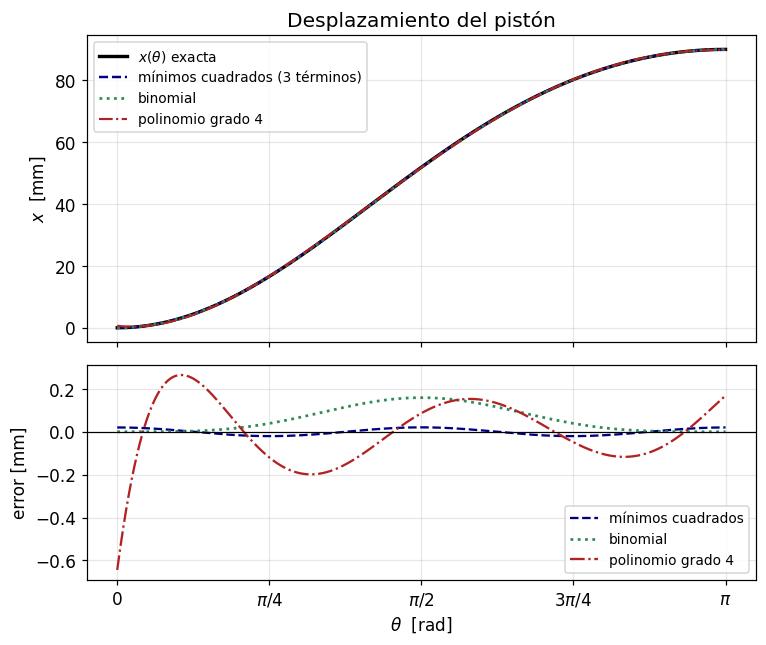

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.2, 6.0), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.4]})

ax1.plot(tt, x_exacta(tt)*1000, "k-", lw=2.2, label=r"$x(\theta)$ exacta")
ax1.plot(tt, P_orto(tt, 3)*1000, "--", color="navy", lw=1.6,
         label="mínimos cuadrados (3 términos)")
ax1.plot(tt, P_binomial(tt)*1000, ":", color="seagreen", lw=1.8, label="binomial")
ax1.plot(tt, P_poly(tt)*1000, "-.", color="firebrick", lw=1.4,
         label=f"polinomio grado {n2}")
ax1.set_ylabel(r"$x$  [mm]")
ax1.set_title("Desplazamiento del pistón")
ax1.legend(fontsize=9)

ax2.plot(tt, (x_exacta(tt) - P_orto(tt, 3))*1000, "--", color="navy",
         label="mínimos cuadrados")
ax2.plot(tt, (x_exacta(tt) - P_binomial(tt))*1000, ":", color="seagreen", lw=1.8,
         label="binomial")
ax2.plot(tt, (x_exacta(tt) - P_poly(tt))*1000, "-.", color="firebrick",
         label=f"polinomio grado {n2}")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel(r"$\theta$  [rad]")
ax2.set_ylabel("error [mm]")
ax2.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

El polinomio de grado 4 en la base monomial, pese a tener 5 coeficientes y una
matriz con $\mathrm{cond} \sim 10^6$, es **el peor** de los tres: la base importa
más que la cantidad de términos.

### 12.5 Para qué sirve: fuerzas de inercia alternativas

Si la manivela gira a velocidad angular constante $\omega$, derivando dos veces la
aproximación $x \approx c_0 + c_1\cos\theta + c_2\cos 2\theta$ con $\theta = \omega t$:

$$ \ddot{x}(\theta) \approx -\omega^2 \left( c_1 \cos\theta + 4 c_2 \cos 2\theta \right) .$$

La fuerza de inercia $F = -m_{alt}\,\ddot{x}$ queda separada en un **armónico
primario** (frecuencia $\omega$) y uno **secundario** (frecuencia $2\omega$), que
es exactamente la información que se necesita para el equilibrado. Esta lectura
es inmediata en la base ortogonal e imposible en la base monomial.

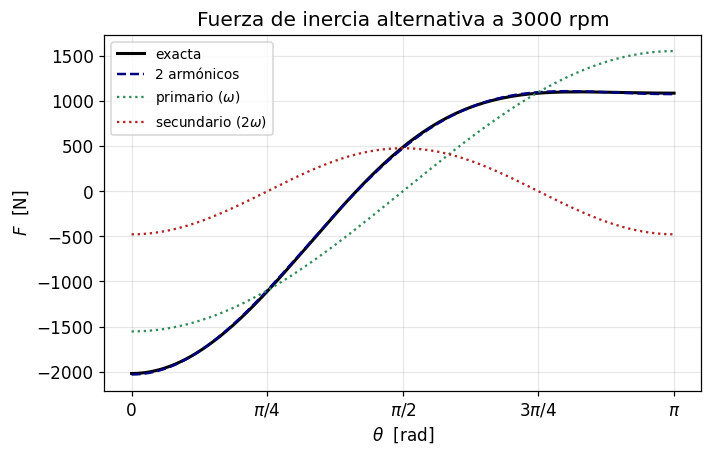

amplitud primaria   =   1554.5 N
amplitud secundaria =    477.3 N
relación sec./prim. =    0.307   (~ lambda = 0.300)


In [48]:
omega = 2 * np.pi * 3000 / 60          # 3000 rpm -> rad/s
m_alt = 0.35                           # masa alternativa, kg

acc_aprox = -omega**2 * (c[1]*np.cos(tt) + 4*c[2]*np.cos(2*tt))

h = 1e-5                               # aceleración exacta por diferencias centradas
acc_exacta = omega**2 * (x_exacta(tt+h) - 2*x_exacta(tt) + x_exacta(tt-h)) / h**2

fig, ax = plt.subplots()
ax.plot(tt, -m_alt*acc_exacta, "k-", lw=2.0, label="exacta")
ax.plot(tt, -m_alt*acc_aprox, "--", color="navy", lw=1.6, label="2 armónicos")
ax.plot(tt, m_alt*omega**2*c[1]*np.cos(tt), ":", color="seagreen",
        label=r"primario ($\omega$)")
ax.plot(tt, 4*m_alt*omega**2*c[2]*np.cos(2*tt), ":", color="firebrick",
        label=r"secundario ($2\omega$)")
ax.set_xlabel(r"$\theta$  [rad]")
ax.set_ylabel(r"$F$  [N]")
ax.set_title(f"Fuerza de inercia alternativa a {omega*60/(2*np.pi):.0f} rpm")
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax.legend(fontsize=9)
plt.show()

print(f"amplitud primaria   = {abs(m_alt*omega**2*c[1]):8.1f} N")
print(f"amplitud secundaria = {abs(4*m_alt*omega**2*c[2]):8.1f} N")
print(f"relación sec./prim. = {abs(4*c[2]/c[1]):8.3f}   (~ lambda = {lam:.3f})")

---
# Síntesis de problemas 5 y 12

| | Bomba centrífuga | Biela-manivela |
|---|---|---|
| Tipo de problema | discreto | continuo |
| Dato de partida | $m$ pares $(Q_i, H_i)$ con ruido | función exacta $x(\theta)$ |
| Funcional | $\sum_i [y_i - P(x_i)]^2$ | $\int_a^b [f - P]^2 d\theta$ |
| Sistema normal | matriz de sumas $S_{j+k}$ | matriz de Hilbert $h_{jk}$ |
| Dificultad | condicionamiento al subir el grado | condicionamiento y base inadecuada |
| Remedio | escalar las abscisas o usar `lstsq` | cambiar a una base ortogonal |
| Resultado útil | punto de funcionamiento | armónicos de la fuerza de inercia |

En ambos casos el sistema normal es el mismo objeto: la proyección ortogonal del
dato sobre el subespacio generado por las funciones de base. Lo que cambia es el
producto interno —suma o integral— y, con él, el condicionamiento del problema
numérico.